# Inference Results Comparison Report

This notebook compares inference/evaluation results across different segmentation experiments:

- **E1**: Baseline comparison (E1-no vs E1-augmentation)
- **E2**: Architecture comparison (E1-augmentation vs E2-2.5D vs E2-3D)
- **E3**: Loss function comparison (E2-2.5D vs E3-CE-Dice vs E3-Dice vs E3-Focal)

The report includes:
- Overall metrics (Mean Dice Score, Mean IoU, Pixel Accuracy)
- Per-class performance metrics
- Inference performance (time, throughput, latency)
- Visual comparisons across experiments


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

# Publication-appropriate sizing for a 174 mm wide figure (~6.85 in).
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 7,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'grid.linewidth': 0.4,
    'patch.linewidth': 0.6,
})

# Base directory
base_dir = Path("/home/s222440401/project/segmentation_experiment")

# ---- Publication figure export setup ----
# Single-column journal width = 84 mm, double-column = 174 mm.
MM_PER_INCH = 25.4
WIDTH_SINGLE_IN = 84.0 / MM_PER_INCH   # ~3.31 in
WIDTH_DOUBLE_IN = 174.0 / MM_PER_INCH  # ~6.85 in

# Output directory for high-resolution figure exports (>= 600 DPI)
FIG_DIR = Path("/home/s222440401/project/segmentation_experiment/report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, fig=None, dpi=600):
    """Save current (or given) figure as PNG and PDF at >= 600 DPI."""
    if fig is None:
        fig = plt.gcf()
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight", facecolor="white")


## 1. Load Evaluation Data


In [20]:
# Define experiment directories and their evaluation report paths
experiments = {
    'E1-no': {
        'dir': base_dir / 'E1-no',
        'eval_dir': base_dir / 'E1-no' / 'evaluation_report'
    },
    'E1-augmentation': {
        'dir': base_dir / 'E1-augmentation',
        'eval_dir': base_dir / 'E1-augmentation' / 'evaluation_report'
    },
    'E2-2.5D': {
        'dir': base_dir / 'E2-2.5D',
        'eval_dir': base_dir / 'E2-2.5D' / 'evaluation_report'
    },
    'E2-3D': {
        'dir': base_dir / 'E2-3D',
        'eval_dir': base_dir / 'E2-3D' / 'evaluation_report_3d'
    },
    'E3-CE-Dice': {
        'dir': base_dir / 'E3-CE-Dice',
        'eval_dir': base_dir / 'E3-CE-Dice' / 'evaluation_report'
    },
    'E3-Dice': {
        'dir': base_dir / 'E3-Dice',
        'eval_dir': base_dir / 'E3-Dice' / 'evaluation_report'
    },
    'E3-Focal': {
        'dir': base_dir / 'E3-Focal',
        'eval_dir': base_dir / 'E3-Focal' / 'evaluation_report'
    }
}

# Load per-class metrics
metrics_data = {}
for exp_name, exp_info in experiments.items():
    metrics_file = exp_info['eval_dir'] / 'metrics_per_class.csv'
    if metrics_file.exists():
        df = pd.read_csv(metrics_file)
        df['experiment'] = exp_name
        metrics_data[exp_name] = df
        print(f"Loaded {exp_name}: {len(df)} classes")

# Combine all metrics
all_metrics = pd.concat(metrics_data.values(), ignore_index=True)
print(f"\nTotal metrics entries: {len(all_metrics)}")


Loaded E1-no: 9 classes
Loaded E1-augmentation: 9 classes
Loaded E2-2.5D: 9 classes
Loaded E2-3D: 9 classes
Loaded E3-CE-Dice: 9 classes
Loaded E3-Dice: 9 classes
Loaded E3-Focal: 9 classes

Total metrics entries: 63


In [21]:
# Function to parse evaluation report text files
def parse_evaluation_report(report_path):
    """Extract metrics from evaluation_report.txt"""
    if not report_path.exists():
        return None
    
    with open(report_path, 'r') as f:
        content = f.read()
    
    metrics = {}
    
    # Extract overall metrics
    mean_acc_match = re.search(r'Mean Pixel Accuracy:\s+([\d.]+)', content)
    mean_dice_match = re.search(r'Mean Dice Score \(macro\):\s+([\d.]+)', content)
    mean_iou_match = re.search(r'Mean IoU Score \(macro\):\s+([\d.]+)', content)
    
    if mean_acc_match:
        metrics['Mean_Pixel_Accuracy'] = float(mean_acc_match.group(1))
    if mean_dice_match:
        metrics['Mean_Dice_Score'] = float(mean_dice_match.group(1))
    if mean_iou_match:
        metrics['Mean_IoU_Score'] = float(mean_iou_match.group(1))
    
    # Extract inference performance
    inf_time_match = re.search(r'Total inference time:\s+([\d.]+)\s+seconds', content)
    batch_time_match = re.search(r'Average batch time:\s+([\d.]+)\s+ms', content)
    throughput_match = re.search(r'Throughput:\s+([\d.]+)\s+samples/second', content)
    latency_match = re.search(r'Latency per sample:\s+([\d.]+)\s+ms', content)
    
    if inf_time_match:
        metrics['Total_Inference_Time_sec'] = float(inf_time_match.group(1))
    if batch_time_match:
        metrics['Average_Batch_Time_ms'] = float(batch_time_match.group(1))
    if throughput_match:
        metrics['Throughput_samples_per_sec'] = float(throughput_match.group(1))
    if latency_match:
        metrics['Latency_per_Sample_ms'] = float(latency_match.group(1))
    
    # Extract number of test samples
    test_samples_match = re.search(r'Number of test (?:samples|volumes):\s+(\d+)', content)
    if test_samples_match:
        metrics['Test_Samples'] = int(test_samples_match.group(1))
    
    return metrics

# Load overall metrics from text reports
overall_metrics = {}
for exp_name, exp_info in experiments.items():
    report_file = exp_info['eval_dir'] / 'evaluation_report.txt'
    metrics = parse_evaluation_report(report_file)
    if metrics:
        metrics['experiment'] = exp_name
        overall_metrics[exp_name] = metrics
        print(f"Loaded overall metrics for {exp_name}")

# Create DataFrame from overall metrics
overall_df = pd.DataFrame(list(overall_metrics.values()))
print(f"\nOverall metrics loaded for {len(overall_df)} experiments")


Loaded overall metrics for E1-no
Loaded overall metrics for E1-augmentation
Loaded overall metrics for E2-2.5D
Loaded overall metrics for E2-3D
Loaded overall metrics for E3-CE-Dice
Loaded overall metrics for E3-Dice
Loaded overall metrics for E3-Focal

Overall metrics loaded for 7 experiments


## 2. E1: Baseline Comparison (No Augmentation vs Augmentation)


In [22]:
# Filter E1 experiments (ids must match loaded CSVs / EXP_CONFIGS keys)
e1_experiments = ['E1-no', 'E1-augmentation']
e1_metrics = all_metrics[all_metrics['experiment'].isin(e1_experiments)].copy()
e1_overall = overall_df[overall_df['experiment'].isin(e1_experiments)].copy()

# Create label mapping for E1 (display names; E1-augmentation folder = preprocessing pipeline in reports)
e1_label_map = {'E1-no': 'E1-base', 'E1-augmentation': 'E1-pre-processing'}
e1_metrics['experiment'] = e1_metrics['experiment'].map(e1_label_map)
e1_overall['experiment'] = e1_overall['experiment'].map(e1_label_map)
e1_experiments_display = ['E1-base', 'E1-pre-processing']

print("E1 Overall Metrics Comparison:")
print("="*80)
print(e1_overall[['experiment', 'Mean_Pixel_Accuracy', 'Mean_Dice_Score', 'Mean_IoU_Score']].to_string(index=False))
print("\nE1 Inference Performance:")
print("="*80)
if 'Total_Inference_Time_sec' in e1_overall.columns:
    print(e1_overall[['experiment', 'Total_Inference_Time_sec', 'Throughput_samples_per_sec', 
                      'Latency_per_Sample_ms']].to_string(index=False))


E1 Overall Metrics Comparison:
       experiment  Mean_Pixel_Accuracy  Mean_Dice_Score  Mean_IoU_Score
          E1-base             0.993892         0.225106        0.213705
E1-pre-processing             0.994128         0.231696        0.220064

E1 Inference Performance:
       experiment  Total_Inference_Time_sec  Throughput_samples_per_sec  Latency_per_Sample_ms
          E1-base                   2257.85                        2.79                 358.39
E1-pre-processing                   2282.11                        2.76                 362.24


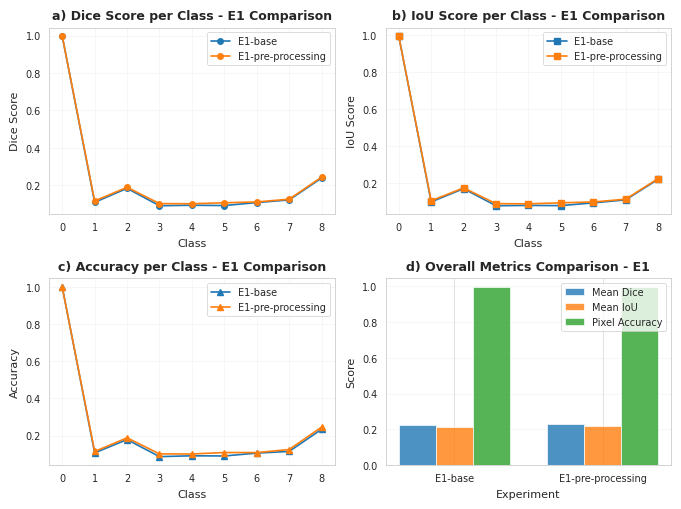

In [23]:
# Per-class comparison for E1
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 12/16))

# Dice Score per class
ax1 = axes[0, 0]
for exp in e1_experiments_display:
    exp_data = e1_metrics[e1_metrics['experiment'] == exp]
    ax1.plot(exp_data['Class'], exp_data['Dice_Score'], marker='o', label=exp, linewidth=1.2)
ax1.set_xlabel('Class', fontsize=8)
ax1.set_ylabel('Dice Score', fontsize=8)
ax1.set_title('a) Dice Score per Class - E1 Comparison', fontsize=9, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(9))

# IoU Score per class
ax2 = axes[0, 1]
for exp in e1_experiments_display:
    exp_data = e1_metrics[e1_metrics['experiment'] == exp]
    ax2.plot(exp_data['Class'], exp_data['IoU_Score'], marker='s', label=exp, linewidth=1.2)
ax2.set_xlabel('Class', fontsize=8)
ax2.set_ylabel('IoU Score', fontsize=8)
ax2.set_title('b) IoU Score per Class - E1 Comparison', fontsize=9, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(9))

# Accuracy per class
ax3 = axes[1, 0]
for exp in e1_experiments_display:
    exp_data = e1_metrics[e1_metrics['experiment'] == exp]
    ax3.plot(exp_data['Class'], exp_data['Accuracy'], marker='^', label=exp, linewidth=1.2)
ax3.set_xlabel('Class', fontsize=8)
ax3.set_ylabel('Accuracy', fontsize=8)
ax3.set_title('c) Accuracy per Class - E1 Comparison', fontsize=9, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(9))

# Bar chart comparing overall metrics
ax4 = axes[1, 1]
x = np.arange(len(e1_experiments_display))
width = 0.25
dice_vals = [e1_overall[e1_overall['experiment'] == exp]['Mean_Dice_Score'].values[0] for exp in e1_experiments_display]
iou_vals = [e1_overall[e1_overall['experiment'] == exp]['Mean_IoU_Score'].values[0] for exp in e1_experiments_display]
acc_vals = [e1_overall[e1_overall['experiment'] == exp]['Mean_Pixel_Accuracy'].values[0] for exp in e1_experiments_display]

ax4.bar(x - width, dice_vals, width, label='Mean Dice', alpha=0.8)
ax4.bar(x, iou_vals, width, label='Mean IoU', alpha=0.8)
ax4.bar(x + width, acc_vals, width, label='Pixel Accuracy', alpha=0.8)
ax4.set_xlabel('Experiment', fontsize=8)
ax4.set_ylabel('Score', fontsize=8)
ax4.set_title('d) Overall Metrics Comparison - E1', fontsize=9, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(e1_experiments_display)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('e1_per_class_metrics')
plt.show()


In [24]:
# Create detailed per-class comparison table for E1
e1_comparison = e1_metrics.pivot_table(
    index='Class',
    columns='experiment',
    values=['Dice_Score', 'IoU_Score', 'Accuracy'],
    aggfunc='first'
).round(4)

print("E1 Per-Class Detailed Comparison:")
print("="*80)
print(e1_comparison)


E1 Per-Class Detailed Comparison:
           Accuracy                   Dice_Score                   IoU_Score  \
experiment  E1-base E1-pre-processing    E1-base E1-pre-processing   E1-base   
Class                                                                          
0            0.9989            0.9977     0.9976            0.9975    0.9953   
1            0.1075            0.1151     0.1081            0.1152    0.0985   
2            0.1790            0.1885     0.1827            0.1885    0.1701   
3            0.0874            0.1021     0.0897            0.1010    0.0778   
4            0.0919            0.1016     0.0924            0.1006    0.0796   
5            0.0910            0.1095     0.0907            0.1054    0.0785   
6            0.1063            0.1092     0.1065            0.1101    0.0933   
7            0.1153            0.1255     0.1207            0.1246    0.1095   
8            0.2342            0.2460     0.2375            0.2425    0.2206   

     

## 3. E2: Architecture Comparison (2D Augmentation vs 2.5D vs 3D)


In [25]:
# Filter E2 experiments
e2_experiments = ['E1-augmentation', 'E2-2.5D', 'E2-3D']
e2_metrics = all_metrics[all_metrics['experiment'].isin(e2_experiments)].copy()
e2_overall = overall_df[overall_df['experiment'].isin(e2_experiments)].copy()

# Create label mapping for E2
e2_label_map = {'E1-augmentation': 'E2-base', 'E2-2.5D': 'E2-2.5D', 'E2-3D': 'E2-3D'}
e2_metrics['experiment'] = e2_metrics['experiment'].map(e2_label_map)
e2_overall['experiment'] = e2_overall['experiment'].map(e2_label_map)
e2_experiments_display = ['E2-base', 'E2-2.5D', 'E2-3D']

print("E2 Overall Metrics Comparison:")
print("="*80)
print(e2_overall[['experiment', 'Mean_Pixel_Accuracy', 'Mean_Dice_Score', 'Mean_IoU_Score']].to_string(index=False))
print("\nE2 Inference Performance:")
print("="*80)
if 'Total_Inference_Time_sec' in e2_overall.columns:
    inf_cols = ['experiment', 'Total_Inference_Time_sec', 'Throughput_samples_per_sec', 'Latency_per_Sample_ms']
    available_cols = [col for col in inf_cols if col in e2_overall.columns]
    print(e2_overall[available_cols].to_string(index=False))


E2 Overall Metrics Comparison:
experiment  Mean_Pixel_Accuracy  Mean_Dice_Score  Mean_IoU_Score
   E2-base             0.994128         0.231696        0.220064
   E2-2.5D             0.994281         0.233290        0.221880
     E2-3D             0.987647         0.282594        0.225970

E2 Inference Performance:
experiment  Total_Inference_Time_sec  Throughput_samples_per_sec  Latency_per_Sample_ms
   E2-base                   2282.11                        2.76                 362.24
   E2-2.5D                   2332.89                        2.70                 370.30
     E2-3D                     70.54                         NaN                    NaN


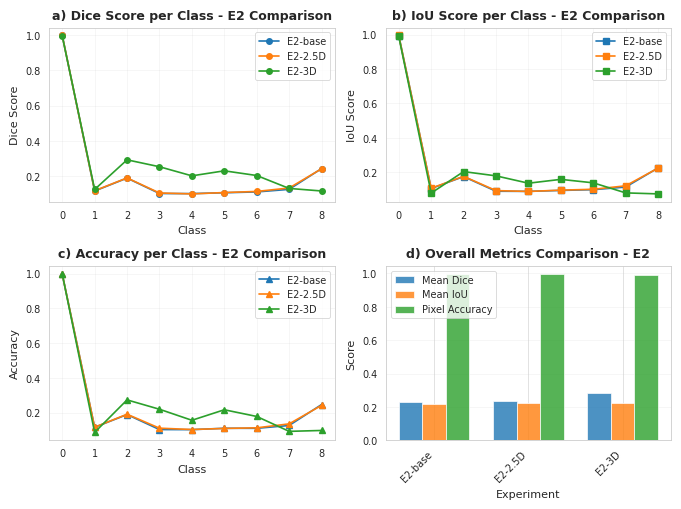

In [26]:
# Visualization for E2
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 12/16))

# Dice Score per class
ax1 = axes[0, 0]
for exp in e2_experiments_display:
    exp_data = e2_metrics[e2_metrics['experiment'] == exp]
    ax1.plot(exp_data['Class'], exp_data['Dice_Score'], marker='o', label=exp, linewidth=1.2)
ax1.set_xlabel('Class', fontsize=8)
ax1.set_ylabel('Dice Score', fontsize=8)
ax1.set_title('a) Dice Score per Class - E2 Comparison', fontsize=9, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(9))

# IoU Score per class
ax2 = axes[0, 1]
for exp in e2_experiments_display:
    exp_data = e2_metrics[e2_metrics['experiment'] == exp]
    ax2.plot(exp_data['Class'], exp_data['IoU_Score'], marker='s', label=exp, linewidth=1.2)
ax2.set_xlabel('Class', fontsize=8)
ax2.set_ylabel('IoU Score', fontsize=8)
ax2.set_title('b) IoU Score per Class - E2 Comparison', fontsize=9, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(9))

# Accuracy per class
ax3 = axes[1, 0]
for exp in e2_experiments_display:
    exp_data = e2_metrics[e2_metrics['experiment'] == exp]
    ax3.plot(exp_data['Class'], exp_data['Accuracy'], marker='^', label=exp, linewidth=1.2)
ax3.set_xlabel('Class', fontsize=8)
ax3.set_ylabel('Accuracy', fontsize=8)
ax3.set_title('c) Accuracy per Class - E2 Comparison', fontsize=9, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(9))

# Bar chart comparing overall metrics
ax4 = axes[1, 1]
x = np.arange(len(e2_experiments_display))
width = 0.25
dice_vals = [e2_overall[e2_overall['experiment'] == exp]['Mean_Dice_Score'].values[0] for exp in e2_experiments_display]
iou_vals = [e2_overall[e2_overall['experiment'] == exp]['Mean_IoU_Score'].values[0] for exp in e2_experiments_display]
acc_vals = [e2_overall[e2_overall['experiment'] == exp]['Mean_Pixel_Accuracy'].values[0] for exp in e2_experiments_display]

ax4.bar(x - width, dice_vals, width, label='Mean Dice', alpha=0.8)
ax4.bar(x, iou_vals, width, label='Mean IoU', alpha=0.8)
ax4.bar(x + width, acc_vals, width, label='Pixel Accuracy', alpha=0.8)
ax4.set_xlabel('Experiment', fontsize=8)
ax4.set_ylabel('Score', fontsize=8)
ax4.set_title('d) Overall Metrics Comparison - E2', fontsize=9, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(e2_experiments_display, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('e2_per_class_metrics')
plt.show()


In [27]:
# Create detailed per-class comparison table for E2
e2_comparison = e2_metrics.pivot_table(
    index='Class',
    columns='experiment',
    values=['Dice_Score', 'IoU_Score', 'Accuracy'],
    aggfunc='first'
).round(4)

print("E2 Per-Class Detailed Comparison:")
print("="*80)
print(e2_comparison)


E2 Per-Class Detailed Comparison:
           Accuracy                 Dice_Score                 IoU_Score  \
experiment  E2-2.5D   E2-3D E2-base    E2-2.5D   E2-3D E2-base   E2-2.5D   
Class                                                                      
0            0.9980  0.9986  0.9977     0.9975  0.9947  0.9975    0.9951   
1            0.1155  0.0859  0.1151     0.1168  0.1242  0.1152    0.1062   
2            0.1904  0.2730  0.1885     0.1895  0.2921  0.1885    0.1757   
3            0.1101  0.2191  0.1021     0.1040  0.2529  0.1010    0.0927   
4            0.1023  0.1555  0.1016     0.0989  0.2013  0.1006    0.0878   
5            0.1085  0.2161  0.1095     0.1065  0.2298  0.1054    0.0953   
6            0.1120  0.1776  0.1092     0.1128  0.2032  0.1101    0.1003   
7            0.1348  0.0917  0.1255     0.1323  0.1298  0.1246    0.1204   
8            0.2415  0.0969  0.2460     0.2413  0.1154  0.2425    0.2235   

                            
experiment   E2-3D E2-ba

## 4. E3: Loss Function Comparison (2.5D vs CE-Dice vs Dice vs Focal)


In [28]:
# Filter E3 experiments
e3_experiments = ['E2-2.5D', 'E3-CE-Dice', 'E3-Dice', 'E3-Focal']
e3_metrics = all_metrics[all_metrics['experiment'].isin(e3_experiments)].copy()
e3_overall = overall_df[overall_df['experiment'].isin(e3_experiments)].copy()

# Create label mapping for E3
e3_label_map = {'E2-2.5D': 'E3-CE', 'E3-CE-Dice': 'E3-CE-Dice', 'E3-Dice': 'E3-Dice', 'E3-Focal': 'E3-Focal'}
e3_metrics['experiment'] = e3_metrics['experiment'].map(e3_label_map)
e3_overall['experiment'] = e3_overall['experiment'].map(e3_label_map)
e3_experiments_display = ['E3-CE', 'E3-CE-Dice', 'E3-Dice', 'E3-Focal']

print("E3 Overall Metrics Comparison:")
print("="*80)
print(e3_overall[['experiment', 'Mean_Pixel_Accuracy', 'Mean_Dice_Score', 'Mean_IoU_Score']].to_string(index=False))
print("\nE3 Inference Performance:")
print("="*80)
if 'Total_Inference_Time_sec' in e3_overall.columns:
    inf_cols = ['experiment', 'Total_Inference_Time_sec', 'Throughput_samples_per_sec', 'Latency_per_Sample_ms']
    available_cols = [col for col in inf_cols if col in e3_overall.columns]
    print(e3_overall[available_cols].to_string(index=False))


E3 Overall Metrics Comparison:
experiment  Mean_Pixel_Accuracy  Mean_Dice_Score  Mean_IoU_Score
     E3-CE             0.994281         0.233290        0.221880
E3-CE-Dice             0.992239         0.231154        0.217391
   E3-Dice             0.993477         0.226945        0.214837
  E3-Focal             0.987283         0.222046        0.203651

E3 Inference Performance:
experiment  Total_Inference_Time_sec  Throughput_samples_per_sec  Latency_per_Sample_ms
     E3-CE                   2332.89                        2.70                 370.30
E3-CE-Dice                   2360.06                        2.67                 374.61
   E3-Dice                   2297.00                        2.74                 364.60
  E3-Focal                   2373.84                        2.65                 376.80


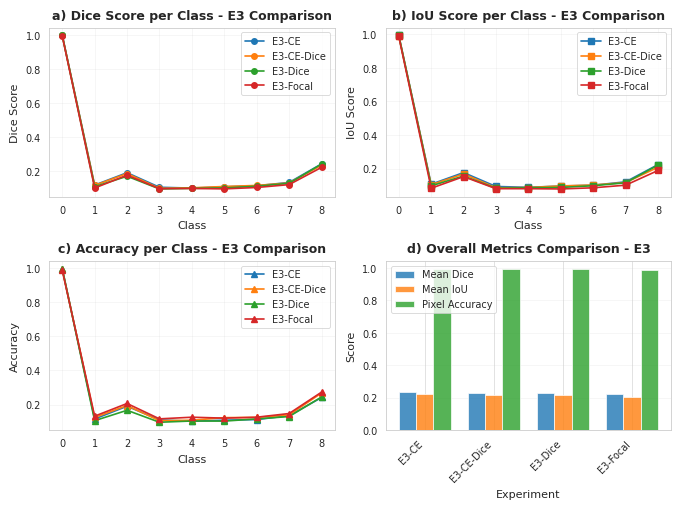

In [29]:
# Visualization for E3
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 12/16))

# Dice Score per class
ax1 = axes[0, 0]
for exp in e3_experiments_display:
    exp_data = e3_metrics[e3_metrics['experiment'] == exp]
    ax1.plot(exp_data['Class'], exp_data['Dice_Score'], marker='o', label=exp, linewidth=1.2)
ax1.set_xlabel('Class', fontsize=8)
ax1.set_ylabel('Dice Score', fontsize=8)
ax1.set_title('a) Dice Score per Class - E3 Comparison', fontsize=9, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(9))

# IoU Score per class
ax2 = axes[0, 1]
for exp in e3_experiments_display:
    exp_data = e3_metrics[e3_metrics['experiment'] == exp]
    ax2.plot(exp_data['Class'], exp_data['IoU_Score'], marker='s', label=exp, linewidth=1.2)
ax2.set_xlabel('Class', fontsize=8)
ax2.set_ylabel('IoU Score', fontsize=8)
ax2.set_title('b) IoU Score per Class - E3 Comparison', fontsize=9, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(9))

# Accuracy per class
ax3 = axes[1, 0]
for exp in e3_experiments_display:
    exp_data = e3_metrics[e3_metrics['experiment'] == exp]
    ax3.plot(exp_data['Class'], exp_data['Accuracy'], marker='^', label=exp, linewidth=1.2)
ax3.set_xlabel('Class', fontsize=8)
ax3.set_ylabel('Accuracy', fontsize=8)
ax3.set_title('c) Accuracy per Class - E3 Comparison', fontsize=9, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(9))

# Bar chart comparing overall metrics
ax4 = axes[1, 1]
x = np.arange(len(e3_experiments_display))
width = 0.25
dice_vals = [e3_overall[e3_overall['experiment'] == exp]['Mean_Dice_Score'].values[0] for exp in e3_experiments_display]
iou_vals = [e3_overall[e3_overall['experiment'] == exp]['Mean_IoU_Score'].values[0] for exp in e3_experiments_display]
acc_vals = [e3_overall[e3_overall['experiment'] == exp]['Mean_Pixel_Accuracy'].values[0] for exp in e3_experiments_display]

ax4.bar(x - width, dice_vals, width, label='Mean Dice', alpha=0.8)
ax4.bar(x, iou_vals, width, label='Mean IoU', alpha=0.8)
ax4.bar(x + width, acc_vals, width, label='Pixel Accuracy', alpha=0.8)
ax4.set_xlabel('Experiment', fontsize=8)
ax4.set_ylabel('Score', fontsize=8)
ax4.set_title('d) Overall Metrics Comparison - E3', fontsize=9, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(e3_experiments_display, rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig('e3_per_class_metrics')
plt.show()


In [30]:
# Create detailed per-class comparison table for E3
e3_comparison = e3_metrics.pivot_table(
    index='Class',
    columns='experiment',
    values=['Dice_Score', 'IoU_Score', 'Accuracy'],
    aggfunc='first'
).round(4)

print("E3 Per-Class Detailed Comparison:")
print("="*80)
print(e3_comparison)


E3 Per-Class Detailed Comparison:
           Accuracy                             Dice_Score                     \
experiment    E3-CE E3-CE-Dice E3-Dice E3-Focal      E3-CE E3-CE-Dice E3-Dice   
Class                                                                           
0            0.9980     0.9944  0.9975   0.9881     0.9975     0.9966  0.9972   
1            0.1155     0.1243  0.1056   0.1321     0.1168     0.1150  0.1072   
2            0.1904     0.1945  0.1665   0.2063     0.1895     0.1848  0.1688   
3            0.1101     0.1051  0.0962   0.1162     0.1040     0.0976  0.0940   
4            0.1023     0.1081  0.1037   0.1258     0.0989     0.1007  0.0976   
5            0.1085     0.1235  0.1030   0.1204     0.1065     0.1084  0.0998   
6            0.1120     0.1247  0.1159   0.1259     0.1128     0.1146  0.1103   
7            0.1348     0.1393  0.1298   0.1475     0.1323     0.1293  0.1272   
8            0.2415     0.2680  0.2446   0.2730     0.2413     0.2333  0.24

## 5. Overall Comparison Across All Experiments


In [31]:
# Overall comparison table
print("Overall Metrics Across All Experiments:")
print("="*80)
comparison_cols = ['experiment', 'Mean_Pixel_Accuracy', 'Mean_Dice_Score', 'Mean_IoU_Score']
if 'Total_Inference_Time_sec' in overall_df.columns:
    comparison_cols.append('Total_Inference_Time_sec')
if 'Throughput_samples_per_sec' in overall_df.columns:
    comparison_cols.append('Throughput_samples_per_sec')

available_cols = [col for col in comparison_cols if col in overall_df.columns]
print(overall_df[available_cols].round(4).to_string(index=False))


Overall Metrics Across All Experiments:
     experiment  Mean_Pixel_Accuracy  Mean_Dice_Score  Mean_IoU_Score  Total_Inference_Time_sec  Throughput_samples_per_sec
          E1-no               0.9939           0.2251          0.2137                   2257.85                        2.79
E1-augmentation               0.9941           0.2317          0.2201                   2282.11                        2.76
        E2-2.5D               0.9943           0.2333          0.2219                   2332.89                        2.70
          E2-3D               0.9876           0.2826          0.2260                     70.54                         NaN
     E3-CE-Dice               0.9922           0.2312          0.2174                   2360.06                        2.67
        E3-Dice               0.9935           0.2269          0.2148                   2297.00                        2.74
       E3-Focal               0.9873           0.2220          0.2037                   2373

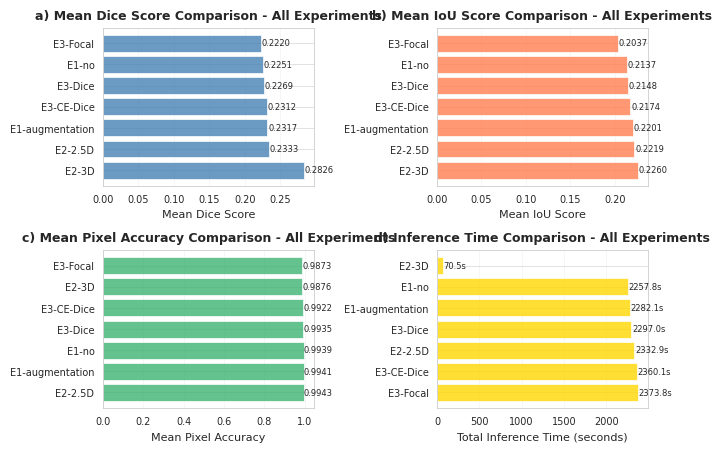

In [32]:
# Comprehensive visualization across all experiments
fig, axes = plt.subplots(2, 2, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 12/18))

# Overall Dice Score comparison
ax1 = axes[0, 0]
dice_comparison = overall_df[['experiment', 'Mean_Dice_Score']].sort_values('Mean_Dice_Score', ascending=False)
ax1.barh(dice_comparison['experiment'], dice_comparison['Mean_Dice_Score'], alpha=0.8, color='steelblue')
ax1.set_xlabel('Mean Dice Score', fontsize=8)
ax1.set_title('a) Mean Dice Score Comparison - All Experiments', fontsize=9, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(dice_comparison['Mean_Dice_Score']):
    ax1.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=6)

# Overall IoU Score comparison
ax2 = axes[0, 1]
iou_comparison = overall_df[['experiment', 'Mean_IoU_Score']].sort_values('Mean_IoU_Score', ascending=False)
ax2.barh(iou_comparison['experiment'], iou_comparison['Mean_IoU_Score'], alpha=0.8, color='coral')
ax2.set_xlabel('Mean IoU Score', fontsize=8)
ax2.set_title('b) Mean IoU Score Comparison - All Experiments', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(iou_comparison['Mean_IoU_Score']):
    ax2.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=6)

# Overall Pixel Accuracy comparison
ax3 = axes[1, 0]
acc_comparison = overall_df[['experiment', 'Mean_Pixel_Accuracy']].sort_values('Mean_Pixel_Accuracy', ascending=False)
ax3.barh(acc_comparison['experiment'], acc_comparison['Mean_Pixel_Accuracy'], alpha=0.8, color='mediumseagreen')
ax3.set_xlabel('Mean Pixel Accuracy', fontsize=8)
ax3.set_title('c) Mean Pixel Accuracy Comparison - All Experiments', fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(acc_comparison['Mean_Pixel_Accuracy']):
    ax3.text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=6)

# Inference time comparison (if available)
ax4 = axes[1, 1]
if 'Total_Inference_Time_sec' in overall_df.columns:
    inf_comparison = overall_df[['experiment', 'Total_Inference_Time_sec']].sort_values('Total_Inference_Time_sec', ascending=False)
    ax4.barh(inf_comparison['experiment'], inf_comparison['Total_Inference_Time_sec'], alpha=0.8, color='gold')
    ax4.set_xlabel('Total Inference Time (seconds)', fontsize=8)
    ax4.set_title('d) Inference Time Comparison - All Experiments', fontsize=9, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    for i, v in enumerate(inf_comparison['Total_Inference_Time_sec']):
        ax4.text(v + 10, i, f'{v:.1f}s', va='center', fontsize=6)
else:
    ax4.text(0.5, 0.5, 'Inference time data not available', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=8)
    ax4.set_title('d) Inference Time Comparison', fontsize=9, fontweight='bold')

plt.tight_layout()
save_fig('all_experiments_overall_metrics')
plt.show()


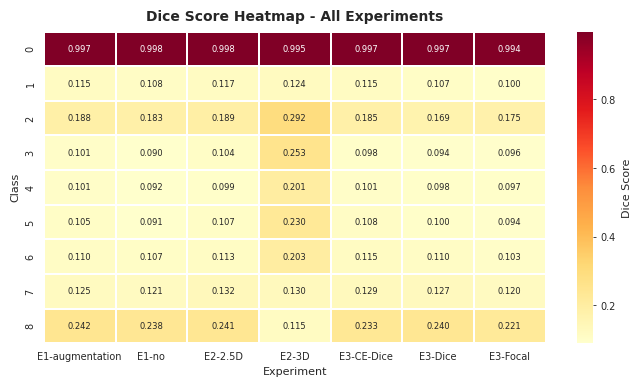

In [33]:
# Heatmap of Dice scores per class across all experiments
pivot_dice = all_metrics.pivot_table(
    index='Class',
    columns='experiment',
    values='Dice_Score',
    aggfunc='first'
)

plt.figure(figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 8/14))
sns.heatmap(pivot_dice, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Dice Score'}, annot_kws={'size': 6}, linewidths=0.3)
plt.title('Dice Score Heatmap - All Experiments', fontsize=10, fontweight='bold', pad=8)
plt.xlabel('Experiment', fontsize=8)
plt.ylabel('Class', fontsize=8)
plt.tight_layout()
save_fig('dice_score_heatmap')
plt.show()


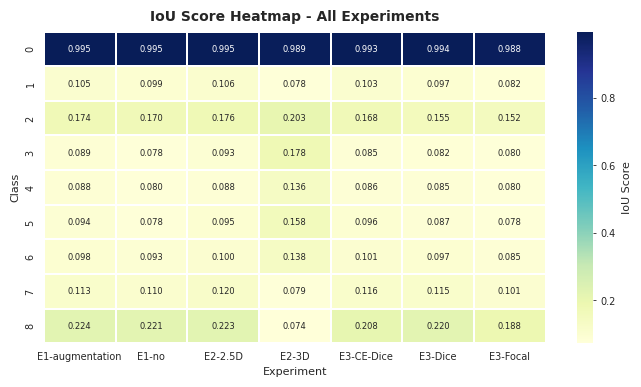

In [34]:
# Heatmap of IoU scores per class across all experiments
pivot_iou = all_metrics.pivot_table(
    index='Class',
    columns='experiment',
    values='IoU_Score',
    aggfunc='first'
)

plt.figure(figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 8/14))
sns.heatmap(pivot_iou, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'IoU Score'}, annot_kws={'size': 6}, linewidths=0.3)
plt.title('IoU Score Heatmap - All Experiments', fontsize=10, fontweight='bold', pad=8)
plt.xlabel('Experiment', fontsize=8)
plt.ylabel('Class', fontsize=8)
plt.tight_layout()
save_fig('iou_score_heatmap')
plt.show()


## 6. Key Findings Summary


In [35]:
print("="*80)
print("SUMMARY OF KEY FINDINGS")
print("="*80)

# Create overall label mapping for summary
overall_label_map = {
    'E1-no': 'E1-base',
    'E1-augmentation': 'E1-augmentation',
    'E2-2.5D': 'E2-2.5D',
    'E2-3D': 'E2-3D',
    'E3-CE-Dice': 'E3-CE-Dice',
    'E3-Dice': 'E3-Dice',
    'E3-Focal': 'E3-Focal'
}

# E1 Comparison
print("\n[E1] Baseline Comparison (No Augmentation vs Augmentation):")
e1_no_dice = overall_df[overall_df['experiment'] == 'E1-no']['Mean_Dice_Score'].values[0]
e1_aug_dice = overall_df[overall_df['experiment'] == 'E1-augmentation']['Mean_Dice_Score'].values[0]
dice_diff = ((e1_aug_dice - e1_no_dice) / e1_no_dice) * 100

e1_no_iou = overall_df[overall_df['experiment'] == 'E1-no']['Mean_IoU_Score'].values[0]
e1_aug_iou = overall_df[overall_df['experiment'] == 'E1-augmentation']['Mean_IoU_Score'].values[0]
iou_diff = ((e1_aug_iou - e1_no_iou) / e1_no_iou) * 100

print(f"  Mean Dice Score: E1-base = {e1_no_dice:.4f}, E1-pre-processing = {e1_aug_dice:.4f} ({dice_diff:+.2f}%)")
print(f"  Mean IoU Score:  E1-base = {e1_no_iou:.4f}, E1-pre-processing = {e1_aug_iou:.4f} ({iou_diff:+.2f}%)")

# E2 Comparison
print("\n[E2] Architecture Comparison:")
e2_base_dice = overall_df[overall_df['experiment'] == 'E1-augmentation']['Mean_Dice_Score'].values[0]
e2_25d_dice = overall_df[overall_df['experiment'] == 'E2-2.5D']['Mean_Dice_Score'].values[0]
e2_3d_dice = overall_df[overall_df['experiment'] == 'E2-3D']['Mean_Dice_Score'].values[0]
e2_base_iou = overall_df[overall_df['experiment'] == 'E1-augmentation']['Mean_IoU_Score'].values[0]
e2_25d_iou = overall_df[overall_df['experiment'] == 'E2-2.5D']['Mean_IoU_Score'].values[0]
e2_3d_iou = overall_df[overall_df['experiment'] == 'E2-3D']['Mean_IoU_Score'].values[0]

print(f"  Mean Dice Score: E2-base = {e2_base_dice:.4f}")
print(f"                   E2-2.5D = {e2_25d_dice:.4f} ({((e2_25d_dice - e2_base_dice) / e2_base_dice) * 100:+.2f}%)")
print(f"                   E2-3D = {e2_3d_dice:.4f} ({((e2_3d_dice - e2_base_dice) / e2_base_dice) * 100:+.2f}%)")
print(f"  Mean IoU Score:  E2-base = {e2_base_iou:.4f}")
print(f"                   E2-2.5D = {e2_25d_iou:.4f} ({((e2_25d_iou - e2_base_iou) / e2_base_iou) * 100:+.2f}%)")
print(f"                   E2-3D = {e2_3d_iou:.4f} ({((e2_3d_iou - e2_base_iou) / e2_base_iou) * 100:+.2f}%)")

# E3 Comparison
print("\n[E3] Loss Function Comparison:")
e3_ce_base_dice = overall_df[overall_df['experiment'] == 'E2-2.5D']['Mean_Dice_Score'].values[0]
e3_ce_dice_dice = overall_df[overall_df['experiment'] == 'E3-CE-Dice']['Mean_Dice_Score'].values[0]
e3_dice_dice = overall_df[overall_df['experiment'] == 'E3-Dice']['Mean_Dice_Score'].values[0]
e3_focal_dice = overall_df[overall_df['experiment'] == 'E3-Focal']['Mean_Dice_Score'].values[0]

e3_ce_base_iou = overall_df[overall_df['experiment'] == 'E2-2.5D']['Mean_IoU_Score'].values[0]
e3_ce_dice_iou = overall_df[overall_df['experiment'] == 'E3-CE-Dice']['Mean_IoU_Score'].values[0]
e3_dice_iou = overall_df[overall_df['experiment'] == 'E3-Dice']['Mean_IoU_Score'].values[0]
e3_focal_iou = overall_df[overall_df['experiment'] == 'E3-Focal']['Mean_IoU_Score'].values[0]

print(f"  Mean Dice Score: E3-CE = {e3_ce_base_dice:.4f}")
print(f"                   E3-CE-Dice = {e3_ce_dice_dice:.4f} ({((e3_ce_dice_dice - e3_ce_base_dice) / e3_ce_base_dice) * 100:+.2f}%)")
print(f"                   E3-Dice = {e3_dice_dice:.4f} ({((e3_dice_dice - e3_ce_base_dice) / e3_ce_base_dice) * 100:+.2f}%)")
print(f"                   E3-Focal = {e3_focal_dice:.4f} ({((e3_focal_dice - e3_ce_base_dice) / e3_ce_base_dice) * 100:+.2f}%)")
print(f"  Mean IoU Score:  E3-CE = {e3_ce_base_iou:.4f}")
print(f"                   E3-CE-Dice = {e3_ce_dice_iou:.4f} ({((e3_ce_dice_iou - e3_ce_base_iou) / e3_ce_base_iou) * 100:+.2f}%)")
print(f"                   E3-Dice = {e3_dice_iou:.4f} ({((e3_dice_iou - e3_ce_base_iou) / e3_ce_base_iou) * 100:+.2f}%)")
print(f"                   E3-Focal = {e3_focal_iou:.4f} ({((e3_focal_iou - e3_ce_base_iou) / e3_ce_base_iou) * 100:+.2f}%)")

# Best performing experiment
best_dice_exp_orig = overall_df.loc[overall_df['Mean_Dice_Score'].idxmax(), 'experiment']
best_dice_exp = overall_label_map.get(best_dice_exp_orig, best_dice_exp_orig)
best_dice_score = overall_df['Mean_Dice_Score'].max()
best_iou_exp_orig = overall_df.loc[overall_df['Mean_IoU_Score'].idxmax(), 'experiment']
best_iou_exp = overall_label_map.get(best_iou_exp_orig, best_iou_exp_orig)
best_iou_score = overall_df['Mean_IoU_Score'].max()

print("\n[Best Performing Models]:")
print(f"  Best Mean Dice Score: {best_dice_exp} ({best_dice_score:.4f})")
print(f"  Best Mean IoU Score:  {best_iou_exp} ({best_iou_score:.4f})")

print("\n" + "="*80)


SUMMARY OF KEY FINDINGS

[E1] Baseline Comparison (No Augmentation vs Augmentation):
  Mean Dice Score: E1-base = 0.2251, E1-pre-processing = 0.2317 (+2.93%)
  Mean IoU Score:  E1-base = 0.2137, E1-pre-processing = 0.2201 (+2.98%)

[E2] Architecture Comparison:
  Mean Dice Score: E2-base = 0.2317
                   E2-2.5D = 0.2333 (+0.69%)
                   E2-3D = 0.2826 (+21.97%)
  Mean IoU Score:  E2-base = 0.2201
                   E2-2.5D = 0.2219 (+0.83%)
                   E2-3D = 0.2260 (+2.68%)

[E3] Loss Function Comparison:
  Mean Dice Score: E3-CE = 0.2333
                   E3-CE-Dice = 0.2312 (-0.92%)
                   E3-Dice = 0.2269 (-2.72%)
                   E3-Focal = 0.2220 (-4.82%)
  Mean IoU Score:  E3-CE = 0.2219
                   E3-CE-Dice = 0.2174 (-2.02%)
                   E3-Dice = 0.2148 (-3.17%)
                   E3-Focal = 0.2037 (-8.22%)

[Best Performing Models]:
  Best Mean Dice Score: E2-3D (0.2826)
  Best Mean IoU Score:  E2-3D (0.2260)



Average Performance for Vertebrae Classes (1-7) by Experiment:
                Dice_Score         IoU_Score         Accuracy        
                      mean     std      mean     std     mean     std
experiment                                                           
E1-augmentation     0.1208  0.0310    0.1087  0.0302   0.1216  0.0306
E1-no               0.1130  0.0328    0.1011  0.0327   0.1112  0.0316
E2-2.5D             0.1230  0.0313    0.1112  0.0304   0.1248  0.0306
E2-3D               0.2047  0.0615    0.1387  0.0471   0.1741  0.0689
E3-CE-Dice          0.1215  0.0298    0.1080  0.0284   0.1313  0.0301
E3-Dice             0.1150  0.0261    0.1027  0.0256   0.1172  0.0243
E3-Focal            0.1119  0.0290    0.0938  0.0266   0.1392  0.0313


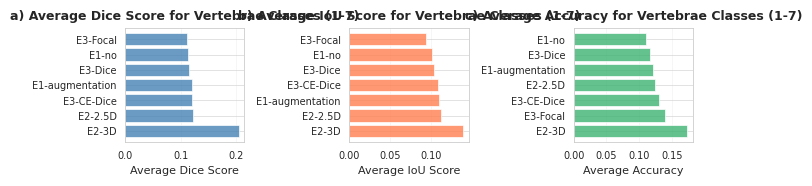

In [36]:
# Analyze per-class performance - focus on vertebrae classes (1-7)
vertebrae_classes = all_metrics[all_metrics['Class'].between(1, 7)].copy()

print("Average Performance for Vertebrae Classes (1-7) by Experiment:")
print("="*80)
vertebrae_summary = vertebrae_classes.groupby('experiment').agg({
    'Dice_Score': ['mean', 'std'],
    'IoU_Score': ['mean', 'std'],
    'Accuracy': ['mean', 'std']
}).round(4)

print(vertebrae_summary)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(WIDTH_DOUBLE_IN, WIDTH_DOUBLE_IN * 5/18))

# Average Dice for vertebrae classes
ax1 = axes[0]
vertebrae_dice = vertebrae_classes.groupby('experiment')['Dice_Score'].mean().sort_values(ascending=False)
ax1.barh(vertebrae_dice.index, vertebrae_dice.values, alpha=0.8, color='steelblue')
ax1.set_xlabel('Average Dice Score', fontsize=8)
ax1.set_title('a) Average Dice Score for Vertebrae Classes (1-7)', fontsize=9, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Average IoU for vertebrae classes
ax2 = axes[1]
vertebrae_iou = vertebrae_classes.groupby('experiment')['IoU_Score'].mean().sort_values(ascending=False)
ax2.barh(vertebrae_iou.index, vertebrae_iou.values, alpha=0.8, color='coral')
ax2.set_xlabel('Average IoU Score', fontsize=8)
ax2.set_title('b) Average IoU Score for Vertebrae Classes (1-7)', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Average Accuracy for vertebrae classes
ax3 = axes[2]
vertebrae_acc = vertebrae_classes.groupby('experiment')['Accuracy'].mean().sort_values(ascending=False)
ax3.barh(vertebrae_acc.index, vertebrae_acc.values, alpha=0.8, color='mediumseagreen')
ax3.set_xlabel('Average Accuracy', fontsize=8)
ax3.set_title('c) Average Accuracy for Vertebrae Classes (1-7)', fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
save_fig('vertebrae_classes_metrics')
plt.show()
